# Phase 6 — AD-Guided Adaptive Sampling

Use the applicability domain to choose **where to run more SWMM**: add points in the sparse, high-error regions Phase 5 flagged, retrain, and check the surrogate improves there. Controlled comparison: **AD-guided (maximin) vs random**, same budget, judged on a fixed held-out SWMM test set.

Design: `docs/superpowers/specs/2026-09-05-phase6-adaptive-sampling-design.md`.

## 1. Setup: training set, surrogate, fixed eval set, SWMM helpers

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def _find_root(marker="PROJECT_BRIEF.md"):
    here = Path.cwd()
    for cand in [here, *here.parents]:
        if (cand / marker).exists():
            return cand
    return here

PROJECT  = _find_root()
DATA_DIR = PROJECT / "data"
RUNS_DIR = PROJECT / "runs"; RUNS_DIR.mkdir(exist_ok=True)
SWMM_EXE = Path(r"D:\EPA SWMM 5.2.4 (64-bit)\runswmm.exe")
BASE_INP = PROJECT / "swmm" / "base_model.inp"
SEED = 42

sys.path.insert(0, str(PROJECT / "scripts"))
from swmm_utils import write_scenario, run_swmm, parse_rpt

FEATURES = ["rain_mult", "imperv_mult", "surf_n", "infil_min", "pipe_n"]

df = pd.read_csv(DATA_DIR / "dataset.csv")
df = df[df["status"] == "ok"].reset_index(drop=True)
Xtrain = df[FEATURES].values
ytrain = df["peak_discharge_cfs"].values

# fixed held-out evaluation set = Phase-5 probes (already have SWMM ground truth)
probes = pd.read_csv(DATA_DIR / "ad_probes.csv")
Xeval = probes[FEATURES].values
yeval = probes["swmm_peak"].values

print(f"training: {len(df)} | fixed eval (Phase-5 probes): {len(probes)}")
assert SWMM_EXE.exists()

training: 500 | fixed eval (Phase-5 probes): 300


## 2. Candidate pool (wide box)

3,000 fresh proposals over the box 50% wider than training each side (physically clipped), a different seed from the probes. No SWMM yet.

In [2]:
mu, sd = Xtrain.mean(0), Xtrain.std(0)
def zscore(X):
    return (np.asarray(X) - mu) / sd

lo, hi = Xtrain.min(0), Xtrain.max(0)
center, half = (lo + hi) / 2, (hi - lo) / 2
WIDEN, N_POOL = 1.5, 3000
wlo, whi = center - WIDEN * half, center + WIDEN * half

rng = np.random.default_rng(SEED + 7)
Pool = rng.uniform(wlo, whi, size=(N_POOL, len(FEATURES)))
idx = {f: i for i, f in enumerate(FEATURES)}
Pool[:, idx["rain_mult"]]   = np.clip(Pool[:, idx["rain_mult"]],   0.1,  None)
Pool[:, idx["imperv_mult"]] = np.clip(Pool[:, idx["imperv_mult"]], 0.1,  None)
Pool[:, idx["surf_n"]]      = np.clip(Pool[:, idx["surf_n"]],      0.005, None)
Pool[:, idx["infil_min"]]   = np.clip(Pool[:, idx["infil_min"]],   0.01, 4.0)
Pool[:, idx["pipe_n"]]      = np.clip(Pool[:, idx["pipe_n"]],      0.005, None)
print("candidate pool:", Pool.shape)

candidate pool: (3000, 5)


## 3. Select 150 points: adaptive (maximin) vs random

**Adaptive:** greedily take the candidate farthest (standardized Euclidean) from the current training set, updating the running min-distance after each pick so chosen points spread out. **Random:** 150 drawn uniformly from the pool.

In [3]:
from scipy.spatial.distance import cdist

N_ADD = 150
Ztrain, Zpool = zscore(Xtrain), zscore(Pool)

# --- adaptive: greedy maximin ---
min_d = cdist(Zpool, Ztrain).min(axis=1)   # dist from each pool pt to nearest training pt
avail = np.ones(N_POOL, dtype=bool)
selected = []
for _ in range(N_ADD):
    cand = np.where(avail, min_d, -np.inf).argmax()
    selected.append(cand); avail[cand] = False
    min_d = np.minimum(min_d, cdist(Zpool, Zpool[cand:cand + 1]).ravel())
adaptive_idx = np.array(selected)

# --- random baseline ---
random_idx = np.random.default_rng(SEED + 99).choice(N_POOL, size=N_ADD, replace=False)

print(f"selected {N_ADD} adaptive + {N_ADD} random from pool")

selected 150 adaptive + 150 random from pool


## 4. Run SWMM on the selected points

In [4]:
base_text = BASE_INP.read_text()

def swmm_peak_for(points, tag):
    ys = []
    for i, p in enumerate(points):
        inp = RUNS_DIR / f"{tag}_{i:03d}.inp"
        inp.write_text(write_scenario(base_text, dict(zip(FEATURES, p))))
        rpt, out, _ = run_swmm(inp, SWMM_EXE)
        ys.append(parse_rpt(rpt.read_text())["peak_discharge_cfs"] if rpt.exists() else np.nan)
        if out.exists():
            out.unlink()
    return np.array(ys)

Xadd_a = Pool[adaptive_idx]; ya = swmm_peak_for(Xadd_a, "adapt")
Xadd_r = Pool[random_idx];   yr = swmm_peak_for(Xadd_r, "rand")
print(f"SWMM ground truth obtained  (adaptive {np.isfinite(ya).sum()}, random {np.isfinite(yr).sum()})")

SWMM ground truth obtained  (adaptive 150, random 150)


## 5. Retrain 3 surrogates & evaluate on the held-out set

Baseline (500) vs 500+random vs 500+adaptive, all judged on the fixed Phase-5 probes.

In [5]:
def make_model():
    return XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=4,
                        subsample=0.9, random_state=SEED)

ma, mr = np.isfinite(ya), np.isfinite(yr)
sets = {
    "baseline_500":        (Xtrain, ytrain),
    f"+{int(mr.sum())}_random":   (np.vstack([Xtrain, Xadd_r[mr]]), np.concatenate([ytrain, yr[mr]])),
    f"+{int(ma.sum())}_adaptive": (np.vstack([Xtrain, Xadd_a[ma]]), np.concatenate([ytrain, ya[ma]])),
}

rows, preds = [], {}
for label, (Xtr, ytr) in sets.items():
    m = make_model(); m.fit(Xtr, ytr)
    pred = m.predict(Xeval); preds[label] = pred
    rows.append({"model": label, "n_train": len(Xtr),
                 "MAE":  mean_absolute_error(yeval, pred),
                 "RMSE": mean_squared_error(yeval, pred) ** 0.5,
                 "R2":   r2_score(yeval, pred)})

res = pd.DataFrame(rows)
print(res.round(3).to_string(index=False))

        model  n_train   MAE  RMSE    R2
 baseline_500      500 1.467 2.136 0.908
  +150_random      650 0.757 1.122 0.975
+150_adaptive      650 0.732 1.098 0.976


## 6. Where did adaptive help? Error by distance quintile

Split the eval set into Mahalanobis-distance quintiles (5 = farthest from training) and compare mean |error| across the three surrogates.

Mean |error| (CFS) by Mahalanobis quintile:
          baseline  random  adaptive
quintile                            
1            0.496   0.436     0.512
2            1.068   0.843     0.910
3            1.255   0.716     0.792
4            1.903   0.795     0.652
5            2.615   0.997     0.795


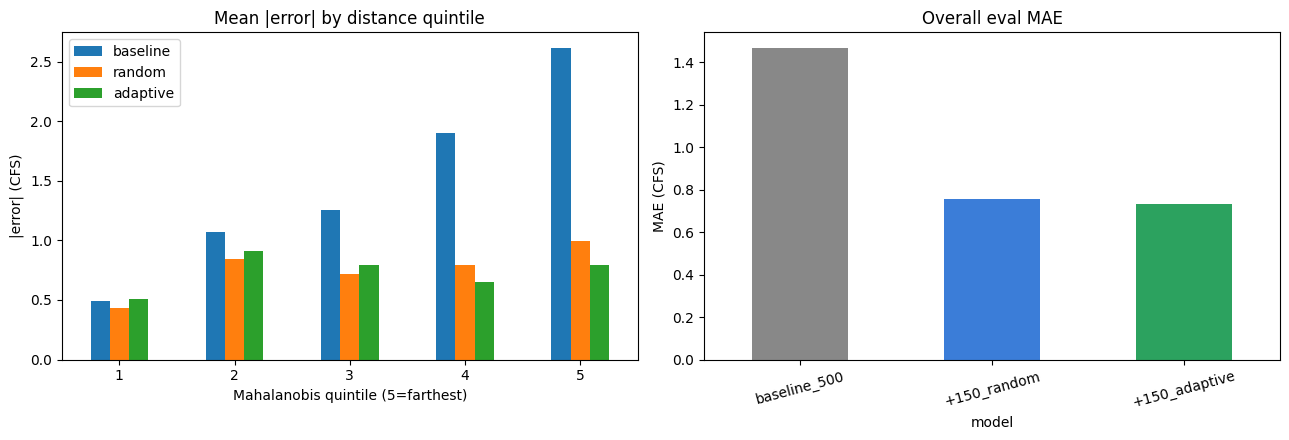

In [6]:
Sigma = np.cov(Xtrain, rowvar=False); Sinv = np.linalg.inv(Sigma)
def maha(X):
    D = np.asarray(X) - mu
    return np.sqrt(np.einsum("ij,jk,ik->i", D, Sinv, D))

d_eval = maha(Xeval)
base_lab = "baseline_500"
rand_lab = [l for l in preds if "random"   in l][0]
adap_lab = [l for l in preds if "adaptive" in l][0]

err = pd.DataFrame({
    "quintile": pd.qcut(d_eval, 5, labels=[1, 2, 3, 4, 5]),
    "baseline": np.abs(yeval - preds[base_lab]),
    "random":   np.abs(yeval - preds[rand_lab]),
    "adaptive": np.abs(yeval - preds[adap_lab]),
})
by_q = err.groupby("quintile", observed=True)[["baseline", "random", "adaptive"]].mean()
print("Mean |error| (CFS) by Mahalanobis quintile:")
print(by_q.round(3))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
by_q.plot.bar(ax=ax[0]); ax[0].set_title("Mean |error| by distance quintile")
ax[0].set_xlabel("Mahalanobis quintile (5=farthest)"); ax[0].set_ylabel("|error| (CFS)")
ax[0].tick_params(axis="x", rotation=0)
res.set_index("model")["MAE"].plot.bar(ax=ax[1], color=["#888", "#3b7dd8", "#2ca25f"])
ax[1].set_title("Overall eval MAE"); ax[1].set_ylabel("MAE (CFS)")
ax[1].tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

## 7. Verdict + save

In [7]:
res.to_csv(DATA_DIR / "adaptive_results.csv", index=False)

base_mae = res.loc[res.model == base_lab, "MAE"].iloc[0]
rand_mae = res.loc[res.model == rand_lab, "MAE"].iloc[0]
adap_mae = res.loc[res.model == adap_lab, "MAE"].iloc[0]

print(f"Held-out MAE:  baseline {base_mae:.3f}  ->  random {rand_mae:.3f}  ->  adaptive {adap_mae:.3f} CFS\n")
print(f"Adaptive vs baseline : {(1 - adap_mae/base_mae)*100:5.1f}% error reduction")
print(f"Adaptive vs random   : {(1 - adap_mae/rand_mae)*100:5.1f}% better than same-budget random")
print("\nSaved -> data/adaptive_results.csv")

Held-out MAE:  baseline 1.467  ->  random 0.757  ->  adaptive 0.732 CFS

Adaptive vs baseline :  50.1% error reduction
Adaptive vs random   :   3.3% better than same-budget random

Saved -> data/adaptive_results.csv
